### Experimental Setup
 - Pick three simulations as described in the paper: Linear, Nonlinear, Random

 - Train on each individual simulation, use a simple linear probe to reconstruct past tokens and see reconstruction error. This will show the hardness of each memorization task

 - Next train on one of the simulations completely, then see whether the autoencoder can remember the other two simulations without being trained on it.

In [4]:
## Load necessary library files ##

import sys
sys.path.append('..')
from sharp.utils import get_sequence, DatasetConverter
from sharp.model.memory import Memory

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch import from_numpy as tnsr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
import pickle 

In [10]:
## select device ##
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # works only with NVIDIA GPUs (not on Mac)
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [11]:
def linear_sequence(total_samples, token_number=7):
    sequence = ""
    for i in range(total_samples):
        sequence += (chr((i % token_number) + ord('A')))
    return sequence

In [12]:
def random_sequence(total_samples, token_number=7):
    sequence = ""
    for i in range(total_samples):
        sequence += chr(np.random.randint(token_number, size=1)[0] + ord('A'))
    return sequence

## Visualize the simulation data ##

In [13]:
print("A 42 tokens long linear sequence ", linear_sequence(42))

## load the nonlinear simulation from source files ##
print("A 42 tokens long nonlinear sequence ", get_sequence(42, n_community=2, n_members=3, train_percent=1.0))

print("A 42 tokens long random sequence ", random_sequence(42))

A 42 tokens long linear sequence  ABCDEFGABCDEFGABCDEFGABCDEFGABCDEFGABCDEFG
A 42 tokens long nonlinear sequence  CABGDEFGDFEGABCGFEDGEDFGFDEGFDEGDEFGEFDGEF
A 42 tokens long random sequence  BEDADFGACDABDFDDGABBBACEDGDCECAAEFFGAEBEBC


In [14]:
## define memory parameters ##
input_size = 7
hidden_size = 100
embedding_dim = 30
total_samples = 10000

In [15]:
## define a linear probe to reconstruct memory ##

class linear_probe(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.linear = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x):
        out = self.linear(x)

        return out 

In [16]:
class Dataset_reconstructer(Dataset):
    def __init__(self, hidden_states, data, past_recall=1, short_term_memory=1):
        
        self.X = np.array(hidden_states)
        self.y = np.array([ord(c)-65 for c in data])
        self.short_term_memory = short_term_memory
        self.past_recall = past_recall

        if short_term_memory == 1:
            self.y = np.concatenate(
                    (np.zeros(past_recall, dtype=int), self.y[:-past_recall])
                )

        self.X = tnsr(self.X)
        self.y = tnsr(self.y).long()

    def __getitem__(self, index):
        return self.X[index], self.y[index+self.short_term_memory-self.past_recall-1]

    def __len__(self):
        return self.X.shape[0]

## Do the first experiment for random sequence

In [17]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc = []
test_acc = []
test_acc_decoder = []
bptt = []
recalls = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = random_sequence(total_samples, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = random_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls.append(past_recall)
            
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy'] = acc 
df['BPTT'] = bptt 
df['Recall'] = recalls

with open('../pickle_files/memory_capacity_random_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [07:03<00:00, 84.62s/it]


Doing reps  2


100%|██████████| 5/5 [08:04<00:00, 96.91s/it] 


Doing reps  3


...

100%|██████████| 5/5 [06:44<00:00, 80.81s/it]


Doing reps  9


100%|██████████| 5/5 [06:32<00:00, 78.45s/it]


Doing reps  10


100%|██████████| 5/5 [07:46<00:00, 93.24s/it]


## Do the first experiment for linear sequence

In [18]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc = []
test_acc = []
test_acc_decoder = []
bptt = []
recalls = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = linear_sequence(total_samples, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = linear_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls.append(past_recall)
            
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy'] = acc 
df['BPTT'] = bptt 
df['Recall'] = recalls

with open('../pickle_files/memory_capacity_linear_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [07:41<00:00, 92.29s/it]


Doing reps  2


100%|██████████| 5/5 [07:35<00:00, 91.18s/it]


Doing reps  3


...

100%|██████████| 5/5 [07:53<00:00, 94.79s/it]


Doing reps  9


100%|██████████| 5/5 [07:23<00:00, 88.71s/it]


Doing reps  10


100%|██████████| 5/5 [07:25<00:00, 89.16s/it]


## Do the first experiment for nonlinear sequence

In [19]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc = []
test_acc = []
test_acc_decoder = []
bptt = []
recalls = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = get_sequence(total_samples, n_community=2, n_members=3, train_percent=1.0)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = get_sequence(10000, n_community=2, n_members=3, train_percent=1.0)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls.append(past_recall)
            
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy'] = acc 
df['BPTT'] = bptt 
df['Recall'] = recalls

with open('../pickle_files/memory_capacity_nonlinear_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [07:52<00:00, 94.50s/it]


Doing reps  2


100%|██████████| 5/5 [08:04<00:00, 96.93s/it]


Doing reps  3


...

100%|██████████| 5/5 [07:46<00:00, 93.32s/it]


Doing reps  9


100%|██████████| 5/5 [08:26<00:00, 101.35s/it]


Doing reps  10


100%|██████████| 5/5 [07:52<00:00, 94.56s/it] 


In [20]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc_linear = []
bptt = []
recalls_linear = []

acc_nonlinear = []
recalls_nonlinear = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = random_sequence(total_samples, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = linear_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc_linear.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls_linear.append(past_recall)

        #########################################
        ### extract the hidden states from the trained RNN ###
        data = get_sequence(10000, n_community=2, n_members=3, train_percent=1.0)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            
            acc_nonlinear.append(correct/len(data_set))
            recalls_nonlinear.append(past_recall)
   
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy Linear'] = acc_linear
df['BPTT'] = bptt 
df['Recall Linear'] = recalls_linear
df['accuracy Nonlinear'] = acc_nonlinear
df['Recall Nonlinear'] = recalls_nonlinear


########################
with open('../pickle_files/memory_capacity_random_pretrained_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [11:27<00:00, 137.42s/it]


Doing reps  2


100%|██████████| 5/5 [12:04<00:00, 144.89s/it]


Doing reps  3


...

100%|██████████| 5/5 [11:34<00:00, 138.85s/it]


Doing reps  9


100%|██████████| 5/5 [12:08<00:00, 145.66s/it]


Doing reps  10


100%|██████████| 5/5 [12:09<00:00, 145.94s/it]


In [21]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc_random = []
bptt = []
recalls_random = []

acc_linear = []
recalls_linear = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = get_sequence(total_samples, n_community=2, n_members=3, train_percent=1.0)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = linear_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc_linear.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls_linear.append(past_recall)

        #########################################
        ### extract the hidden states from the trained RNN ###
        data = random_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            
            acc_random.append(correct/len(data_set))
            recalls_random.append(past_recall)
   
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy Linear'] = acc_linear
df['BPTT'] = bptt 
df['Recall Linear'] = recalls_linear
df['accuracy Random'] = acc_random
df['Recall Random'] = recalls_random


########################
with open('../pickle_files/memory_capacity_nonlinear_pretrained_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [11:38<00:00, 139.69s/it]


Doing reps  2


100%|██████████| 5/5 [11:54<00:00, 142.83s/it]


Doing reps  3


...

100%|██████████| 5/5 [11:27<00:00, 137.44s/it]


Doing reps  9


100%|██████████| 5/5 [10:13<00:00, 122.64s/it]


Doing reps  10


100%|██████████| 5/5 [10:16<00:00, 123.24s/it]


In [22]:
reps = 10
short_term_memories = [2,3,4,5,6]
past_recalls = [2,3,4,5,6]
lr = 6e-4
repitition = []
acc_random = []
bptt = []
recalls_random = []

acc_nonlinear = []
recalls_nonlinear = []


for rep in range(reps):
    print("Doing reps ", rep+1)
    for short_term_memory in tqdm(short_term_memories):
        model = Memory(input_size, hidden_size, embedding_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = nn.functional.cross_entropy

        data = linear_sequence(total_samples, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        h_ = None
        for x, y in train_loader:
            recon_logit, h0, h_ = model(x, h_)
            B, T, V = recon_logit.shape
            recon_loss = nn.functional.cross_entropy(recon_logit.reshape(B*T, V), x.reshape(B*T))

            optimizer.zero_grad()  
            recon_loss.backward()

            optimizer.step()

            with torch.no_grad():
                h_ = h_.detach()


        ### extract the hidden states from the trained RNN ###
        data = random_sequence(10000, token_number=input_size)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            #print('Totoal accuracy :', correct/len(data_set))
            repitition.append(rep)
            acc_random.append(correct/len(data_set))
            bptt.append(short_term_memory)
            recalls_random.append(past_recall)

        #########################################
        ### extract the hidden states from the trained RNN ###
        data = get_sequence(10000, n_community=2, n_members=3, train_percent=1.0)
        data_set = DatasetConverter(data, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        hidden_states = []
        h = None

        for x, y in train_loader:
            with torch.no_grad():
                h = model.encode_step_from_token(x[:,-1], h)

                hidden_states.append(
                    h[0][0]
                )

        ### train classifier to reconstruct past tokens ###
        for past_recall in past_recalls:
            #print('Doing recall ', past_recall)
            data_set = Dataset_reconstructer(hidden_states, data, short_term_memory=short_term_memory, past_recall=past_recall)
            reconstruct_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            reconstructor = linear_probe(input_size, hidden_size)
            optimizer = torch.optim.SGD(reconstructor.parameters(), lr=lr, momentum=0.95)
            criterion = torch.nn.CrossEntropyLoss()

            total = 0
            # correct = np.zeros(1000,dtype=float)
            #print('Training reconstruction classifier ...')
            for epoch in range(10):
                for X, y in reconstruct_loader:
                    optimizer.zero_grad()

                    y_pred = reconstructor(X)
                    

                    loss = criterion(y_pred, y)     
                    loss.backward()
                    optimizer.step()

            #print("Evaluating reconstruction ...")
            correct = 0
            for X, y in reconstruct_loader:
                with torch.no_grad():
                    y_pred = reconstructor(X)
                    
                    if y_pred.argmax() == y:
                        correct += 1

            
            acc_nonlinear.append(correct/len(data_set))
            recalls_nonlinear.append(past_recall)
   
            
            
df = pd.DataFrame()
df['reps'] = repitition
df['accuracy Nonlinear'] = acc_nonlinear
df['BPTT'] = bptt 
df['Recall Nonlinear'] = recalls_nonlinear
df['accuracy Random'] = acc_random
df['Recall Random'] = recalls_random


########################
with open('../pickle_files/memory_capacity_linear_pretrained_autoencoder.pickle', 'wb') as f:
    pickle.dump(df, f)

Doing reps  1


100%|██████████| 5/5 [10:07<00:00, 121.51s/it]


Doing reps  2


100%|██████████| 5/5 [10:15<00:00, 123.13s/it]


Doing reps  3


...

100%|██████████| 5/5 [10:23<00:00, 124.70s/it]


Doing reps  9


100%|██████████| 5/5 [09:42<00:00, 116.49s/it]


Doing reps  10


100%|██████████| 5/5 [09:14<00:00, 110.94s/it]


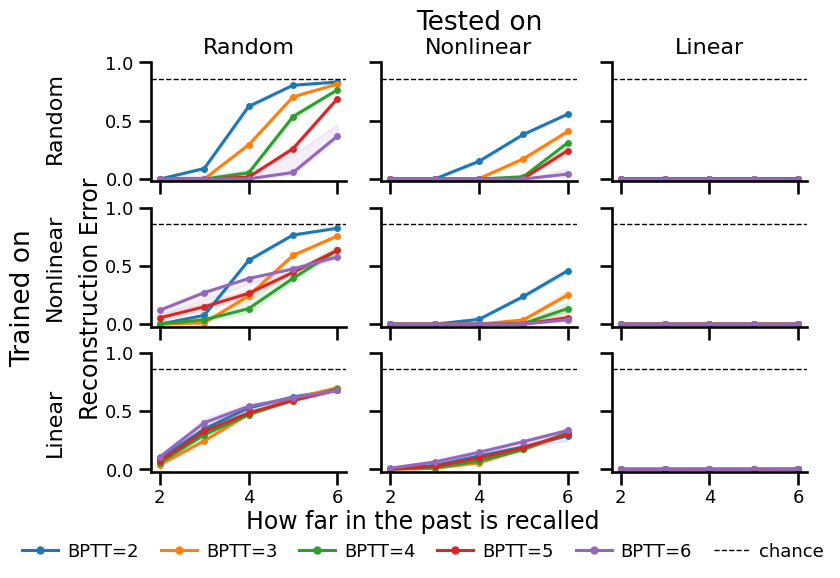

In [19]:
# ===================== LOAD =====================
with open('../pickle_files/memory_capacity_random_autoencoder.pickle', 'rb') as f:
    df_random = pickle.load(f)

with open('../pickle_files/memory_capacity_linear_autoencoder.pickle', 'rb') as f:
    df_linear = pickle.load(f)

with open('../pickle_files/memory_capacity_nonlinear_autoencoder.pickle', 'rb') as f:
    df_nonlinear = pickle.load(f)

with open('../pickle_files/memory_capacity_random_pretrained_autoencoder.pickle', 'rb') as f:
    df_random_pre = pickle.load(f)

with open('../pickle_files/memory_capacity_nonlinear_pretrained_autoencoder.pickle', 'rb') as f:
    df_nonlinear_pre = pickle.load(f)

with open('../pickle_files/memory_capacity_linear_pretrained_autoencoder.pickle', 'rb') as f:
    df_linear_pre = pickle.load(f)

# ===================== SETTINGS =====================
sns.set_context("talk")
fontsize = 17

reps = 10
bptts = [2, 3, 4, 5, 6]
past_recalls = [2, 3, 4, 5, 6]

cmap = plt.get_cmap("tab10")
color_map = {bptt: cmap(i) for i, bptt in enumerate(bptts)}
fill_alpha = 0.10

dataset_order = ["Random", "Nonlinear", "Linear"]

train_top = {
    "Random": df_random,
    "Nonlinear": df_nonlinear,
    "Linear": df_linear,
}

train_pre = {
    "Random": df_random_pre,
    "Nonlinear": df_nonlinear_pre,
    "Linear": df_linear_pre,
}

# ===================== HELPERS =====================
def plot_panel(ax_sub, result_dict, xvals):
    for bptt in bptts:
        arr = np.asarray(result_dict[str(bptt)], dtype=float)

        y = np.nanmedian(arr, axis=0)
        y25 = np.nanquantile(arr, 0.25, axis=0)
        y75 = np.nanquantile(arr, 0.75, axis=0)

        ax_sub.plot(
            xvals,
            y,
            color=color_map[bptt],
            linewidth=2.2,
            marker='o',
            markersize=5,
            markeredgewidth=0,
            label=f"BPTT={bptt}"
        )
        ax_sub.fill_between(
            xvals,
            y25,
            y75,
            color=color_map[bptt],
            alpha=fill_alpha
        )

def collect_in_distribution(df):
    result = {str(b): [] for b in bptts}
    for rep in range(reps):
        for bptt in bptts:
            sub = df[(df["BPTT"] == bptt) & (df["reps"] == rep)].copy()
            vals = list(1.0 - sub["accuracy"].values)
            result[str(bptt)].append(vals)
    return result

def collect_cross_distribution(df_pre, eval_dataset):
    acc_col = f"accuracy {eval_dataset}"
    rec_col = f"Recall {eval_dataset}"

    result = {str(b): [] for b in bptts}
    for rep in range(reps):
        for bptt in bptts:
            sub = df_pre[(df_pre["BPTT"] == bptt) & (df_pre["reps"] == rep)][[rec_col, acc_col]].copy()
            sub = sub.sort_values(rec_col)

            rec_to_err = {
                int(r): float(1.0 - a)
                for r, a in zip(sub[rec_col].values, sub[acc_col].values)
            }
            row = [rec_to_err.get(int(r), np.nan) for r in past_recalls]
            result[str(bptt)].append(row)
    return result

# ===================== FIGURE =====================
fig, ax = plt.subplots(
    3, 3,
    figsize=(8.0, 6.2),
    sharex=True,
    sharey=True
)

for i, train_name in enumerate(dataset_order):
    for j, test_name in enumerate(dataset_order):
        ax_sub = ax[i, j]

        if train_name == test_name:
            res = collect_in_distribution(train_top[train_name])
        else:
            res = collect_cross_distribution(train_pre[train_name], test_name)

        plot_panel(ax_sub, res, past_recalls)

        chance = 1 - 1 / 7.0
        ax_sub.axhline(chance, linestyle="--", color="black", linewidth=1.0)

        ax_sub.spines["right"].set_visible(False)
        ax_sub.spines["top"].set_visible(False)
        ax_sub.set_xlim([1.8, 6.2])
        ax_sub.set_ylim([-0.02, 1.0])
        ax_sub.set_xticks([2,4,6])
        ax_sub.set_yticks([0.0, 0.5, 1.0])
        ax_sub.tick_params(labelsize=fontsize - 4)

        if i == 0:
            ax_sub.set_title(test_name, fontsize=fontsize-1, pad=6)

# global labels
fig.supxlabel("How far in the past is recalled", fontsize=fontsize, y=0.12)
fig.supylabel("Reconstruction Error", fontsize=fontsize, x=0.07)

# row labels only
row_y = [0.79, 0.55, 0.3]
for y, train_name in zip(row_y, dataset_order):
    fig.text(
        0.04, y, train_name,
        va="center", ha="center",
        rotation=90,
        fontsize=fontsize-1
    )

# legend
bptt_handles = [
    plt.Line2D([0], [0], color=color_map[bptt], linewidth=2.2, marker='o', markersize=5)
    for bptt in bptts
]
bptt_labels = [f"BPTT={bptt}" for bptt in bptts]
chance_handle = plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.0)

fig.legend(
    bptt_handles + [chance_handle],
    bptt_labels + ["chance"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=6,
    frameon=False,
    fontsize=fontsize - 4,
    handletextpad=0.5,
    columnspacing=1.2
)

plt.subplots_adjust(
    left=0.16,
    right=0.98,
    top=0.88,
    bottom=0.22,
    wspace=0.18,
    hspace=0.22
)

fig.text(0.57, 0.965, "Tested on", ha="center", va="top", fontsize=fontsize+2)
fig.text(0.00, 0.5, "Trained on", ha="center", va="center", rotation=90, fontsize=fontsize+2)

plt.savefig("../plots/memory_capacity_RNN_autoencoder_3x3.pdf", bbox_inches="tight")
plt.show()